[![Roboflow Notebooks](https://media.roboflow.com/notebooks/template/bannertest2-2.png?ik-sdk-version=javascript-1.4.3&updatedAt=1672932710194)](https://github.com/roboflow/notebooks)

# How to Train YOLOv8 Object Detection on a Custom Dataset

---

[![Roboflow](https://raw.githubusercontent.com/roboflow-ai/notebooks/main/assets/badges/roboflow-blogpost.svg)](https://blog.roboflow.com/how-to-train-yolov8-on-a-custom-dataset)
[![YouTube](https://badges.aleen42.com/src/youtube.svg)](https://youtu.be/wuZtUMEiKWY)
[![GitHub](https://badges.aleen42.com/src/github.svg)](https://github.com/ultralytics/ultralytics)

Ultralytics YOLOv8 is the latest version of the YOLO (You Only Look Once) object detection and image segmentation model developed by Ultralytics. The YOLOv8 model is designed to be fast, accurate, and easy to use, making it an excellent choice for a wide range of object detection and image segmentation tasks. It can be trained on large datasets and is capable of running on a variety of hardware platforms, from CPUs to GPUs.

## ⚠️ Disclaimer

YOLOv8 is still under heavy development. Breaking changes are being introduced almost weekly. We strive to make our YOLOv8 notebooks work with the latest version of the library. Last tests took place on **27.01.2023** with version **YOLOv8.0.20**.

If you notice that our notebook behaves incorrectly - especially if you experience errors that prevent you from going through the tutorial - don't hesitate! Let us know and open an [issue](https://github.com/roboflow/notebooks/issues) on the Roboflow Notebooks repository.

## Accompanying Blog Post

We recommend that you follow along in this notebook while reading the blog post on how to train YOLOv8 Object Detection, concurrently.

## Pro Tip: Use GPU Acceleration

If you are running this notebook in Google Colab, navigate to `Edit` -> `Notebook settings` -> `Hardware accelerator`, set it to `GPU`, and then click `Save`. This will ensure your notebook uses a GPU, which will significantly speed up model training times.

## Steps in this Tutorial

In this tutorial, we are going to cover:

- Before you start
- Install YOLOv8
- CLI Basics
- Inference with Pre-trained COCO Model
- Roboflow Universe
- Preparing a custom dataset
- Custom Training
- Validate Custom Model
- Inference with Custom Model

**Let's begin!**

## Before you start

Let's make sure that we have access to GPU. We can use `nvidia-smi` command to do that. In case of any problems navigate to `Edit` -> `Notebook settings` -> `Hardware accelerator`, set it to `GPU`, and then click `Save`.

In [16]:
#Colab’da GPU aktif mi kontrol eder; ekran kartı modeli ve VRAM’i gösterir.
!nvidia-smi

Wed Dec 17 18:34:32 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8              9W /   70W |       2MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [17]:
#Notebook’un çalıştığı ana dizini (genelde /content) belirler.
import os
HOME = os.getcwd()
print("HOME:", HOME)

HOME: /content/datasets


## Install YOLOv8

⚠️ YOLOv8 is still under heavy development. Breaking changes are being introduced almost weekly. We strive to make our YOLOv8 notebooks work with the latest version of the library. Last tests took place on **27.01.2023** with version **YOLOv8.0.20**.

If you notice that our notebook behaves incorrectly - especially if you experience errors that prevent you from going through the tutorial - don't hesitate! Let us know and open an [issue](https://github.com/roboflow/notebooks/issues) on the Roboflow Notebooks repository.

YOLOv8 can be installed in two ways - from the source and via pip. This is because it is the first iteration of YOLO to have an official package.

In [18]:
#Ultralytics (YOLOv8) paketini temizleyip güncel sürümü kurar.
!pip uninstall -y ultralytics -q
!pip install -q ultralytics

In [19]:
from IPython import display
display.clear_output()

import ultralytics
ultralytics.checks()

Ultralytics 8.3.240 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 40.1/112.6 GB disk)


## CLI Basics

If you want to train, validate or run inference on models and don't need to make any modifications to the code, using YOLO command line interface is the easiest way to get started. Read more about CLI in [Ultralytics YOLO Docs](https://docs.ultralytics.com/usage/cli/).

```
yolo task=detect    mode=train    model=yolov8n.yaml      args...
          classify       predict        yolov8n-cls.yaml  args...
          segment        val            yolov8n-seg.yaml  args...
                         export         yolov8n.pt        format=onnx  args...
```

## Inference with Pre-trained COCO Model

### 💻 CLI

`yolo mode=predict` runs YOLOv8 inference on a variety of sources, downloading models automatically from the latest YOLOv8 release, and saving results to `runs/predict`.

## Roboflow Universe

Need data for your project? Before spending time on annotating, check out Roboflow Universe, a repository of more than 110,000 open-source datasets that you can use in your projects. You'll find datasets containing everything from annotated cracks in concrete to plant images with disease annotations.


[![Roboflow Universe](https://media.roboflow.com/notebooks/template/uni-banner-frame.png?ik-sdk-version=javascript-1.4.3&updatedAt=1672878480290)](https://universe.roboflow.com/)



## Preparing a custom dataset

Building a custom dataset can be a painful process. It might take dozens or even hundreds of hours to collect images, label them, and export them in the proper format. Fortunately, Roboflow makes this process as straightforward and fast as possible. Let me show you how!

### Step 1: Creating project

Before you start, you need to create a Roboflow [account](https://app.roboflow.com/login). Once you do that, you can create a new project in the Roboflow [dashboard](https://app.roboflow.com/). Keep in mind to choose the right project type. In our case, Object Detection.

<div align="center">
  <img
    width="640"
    src="https://media.roboflow.com/preparing-custom-dataset-example/creating-project.gif?ik-sdk-version=javascript-1.4.3&updatedAt=1672929799852"
  >
</div>

### Step 2: Uploading images

Next, add the data to your newly created project. You can do it via API or through our [web interface](https://docs.roboflow.com/adding-data/object-detection).

If you drag and drop a directory with a dataset in a supported format, the Roboflow dashboard will automatically read the images and annotations together.

<div align="center">
  <img
    width="640"
    src="https://media.roboflow.com/preparing-custom-dataset-example/uploading-images.gif?ik-sdk-version=javascript-1.4.3&updatedAt=1672929808290"
  >
</div>

### Step 3: Labeling

If you only have images, you can label them in [Roboflow Annotate](https://docs.roboflow.com/annotate).

<div align="center">
  <img
    width="640"
    src="https://user-images.githubusercontent.com/26109316/210901980-04861efd-dfc0-4a01-9373-13a36b5e1df4.gif"
  >
</div>

### Step 4: Generate new dataset version

Now that we have our images and annotations added, we can Generate a Dataset Version. When Generating a Version, you may elect to add preprocessing and augmentations. This step is completely optional, however, it can allow you to significantly improve the robustness of your model.

<div align="center">
  <img
    width="640"
    src="https://media.roboflow.com/preparing-custom-dataset-example/generate-new-version.gif?ik-sdk-version=javascript-1.4.3&updatedAt=1673003597834"
  >
</div>

### Step 5: Exporting dataset

Once the dataset version is generated, we have a hosted dataset we can load directly into our notebook for easy training. Click `Export` and select the `YOLO v5 PyTorch` dataset format.

<div align="center">
  <img
    width="640"
    src="https://media.roboflow.com/preparing-custom-dataset-example/export.gif?ik-sdk-version=javascript-1.4.3&updatedAt=1672943313709"
  >
</div>




In [20]:
!mkdir -p {HOME}/datasets
%cd {HOME}/datasets

!pip install roboflow --quiet

# paste code snippet from Exporting Dataset
from roboflow import Roboflow
from pathlib import Path

rf = Roboflow(api_key="xjB7LHpyHPxXRZQuQLiC")   # buraya key
project = rf.workspace("pruida").project("revised_data_set")
version = project.version(3)

# Dataset indir (YOLOv8 format)
# Roboflow’daki etiketli veriyi Colab’a indirir ve YOLO formatında hazırlar.
dataset = version.download("yolov8")

# data.yaml yolu
#DATA_YAML = YOLO’nun train/val/test yollarını ve class isimlerini okuduğu ana dosya.
DATA_YAML = Path(dataset.location) / "data.yaml"

print("✅ dataset.location:", dataset.location)
print("✅ DATA_YAML:", DATA_YAML)
print("✅ exists?:", DATA_YAML.exists())


/content/datasets/datasets
loading Roboflow workspace...
loading Roboflow project...
✅ dataset.location: /content/datasets/datasets/revised_data_set-3
✅ DATA_YAML: /content/datasets/datasets/revised_data_set-3/data.yaml
✅ exists?: True


## Custom Training

In [21]:
#YOLOv8n (nano) modelini, senin datasetin üzerinde eğitir:
#görüntüyü okur
#etiketleri okur
#model ağırlıklarını optimize eder
#metrik ve görselleri runs/... içine yazar

%cd {HOME}
!yolo task=detect mode=train model=yolov8n.pt data="{DATA_YAML}" epochs=1 imgsz=640 batch=16 patience=30 workers=2 project="{HOME}/runs" name="revised_v3_yolov8n" exist_ok=True


/content/datasets
Ultralytics 8.3.240 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/datasets/datasets/revised_data_set-3/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=1, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=revised_v3_yolov8n, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask

In [22]:
from pathlib import Path

RUN_DIR = Path(HOME) / "runs" / "revised_v3_yolov8n"
WEIGHTS_DIR = RUN_DIR / "weights"
BEST = WEIGHTS_DIR / "best.pt"
LAST = WEIGHTS_DIR / "last.pt"

print("✅ RUN_DIR:", RUN_DIR)
print("✅ BEST:", BEST, "exists?", BEST.exists())
print("✅ LAST:", LAST, "exists?", LAST.exists())

✅ RUN_DIR: /content/datasets/runs/revised_v3_yolov8n
✅ BEST: /content/datasets/runs/revised_v3_yolov8n/weights/best.pt exists? True
✅ LAST: /content/datasets/runs/revised_v3_yolov8n/weights/last.pt exists? True


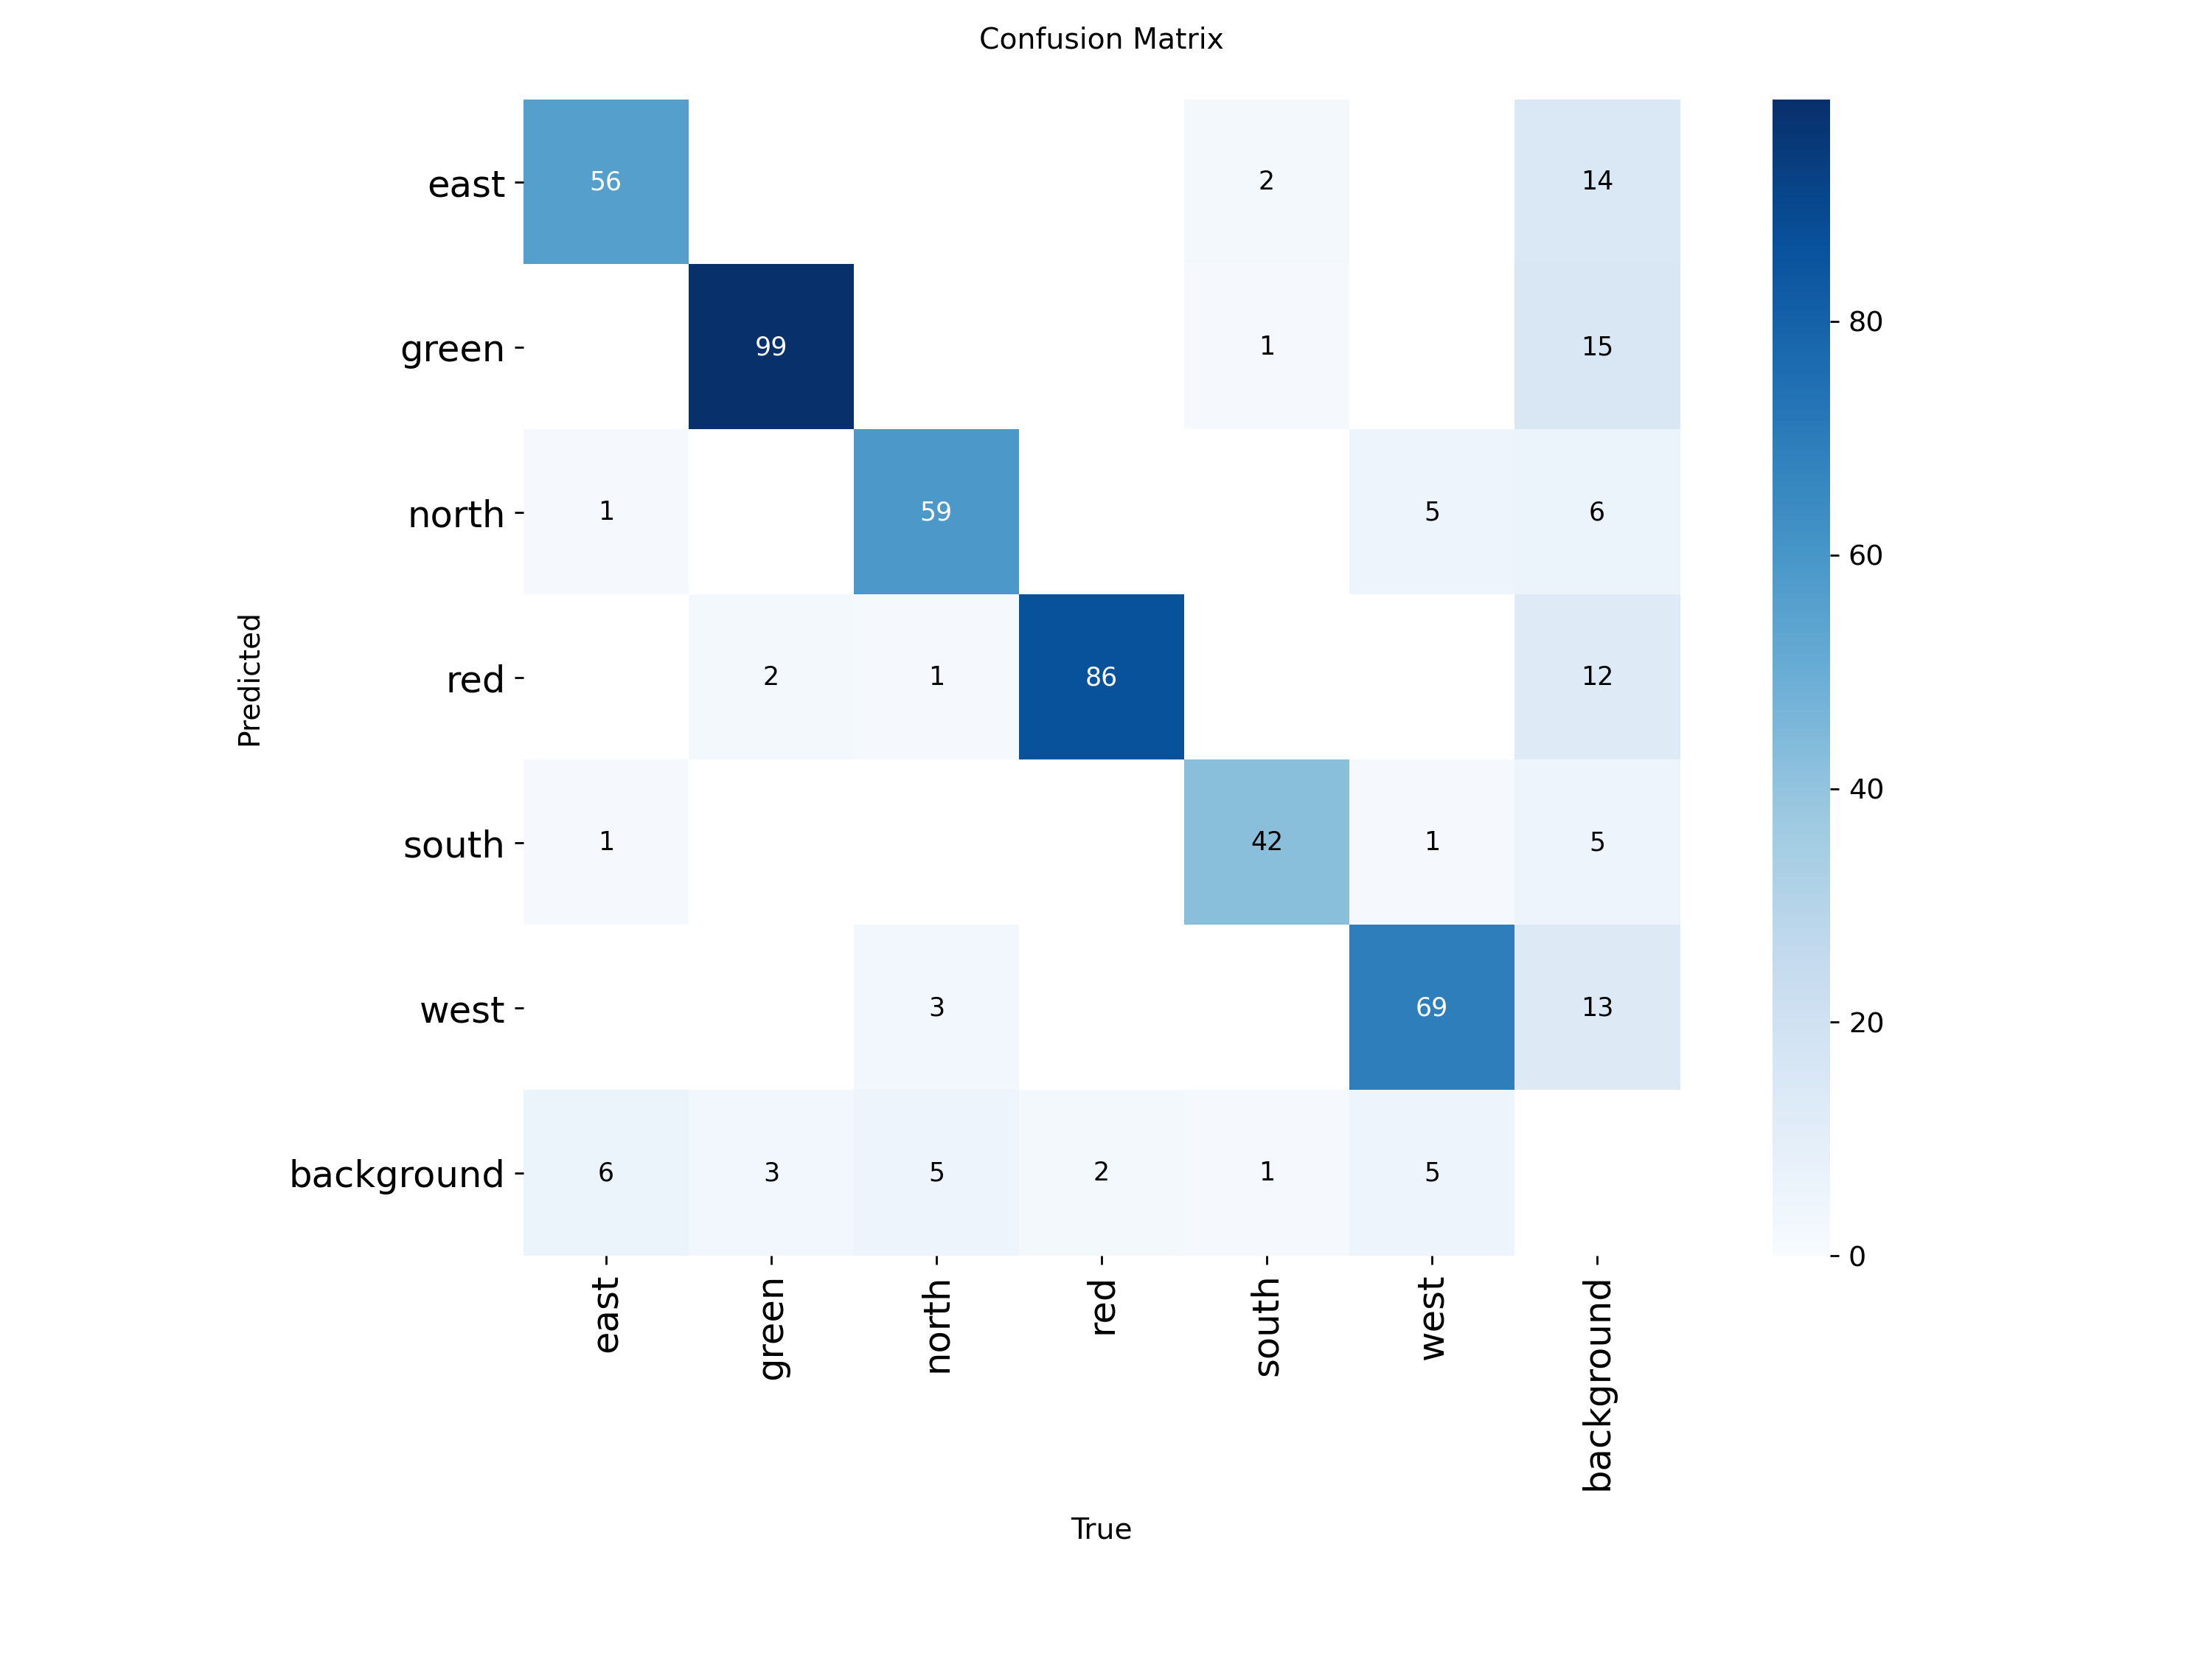

In [23]:
from IPython.display import Image
Image(filename=f"{HOME}/runs/revised_v3_yolov8n/confusion_matrix.png", width=800)


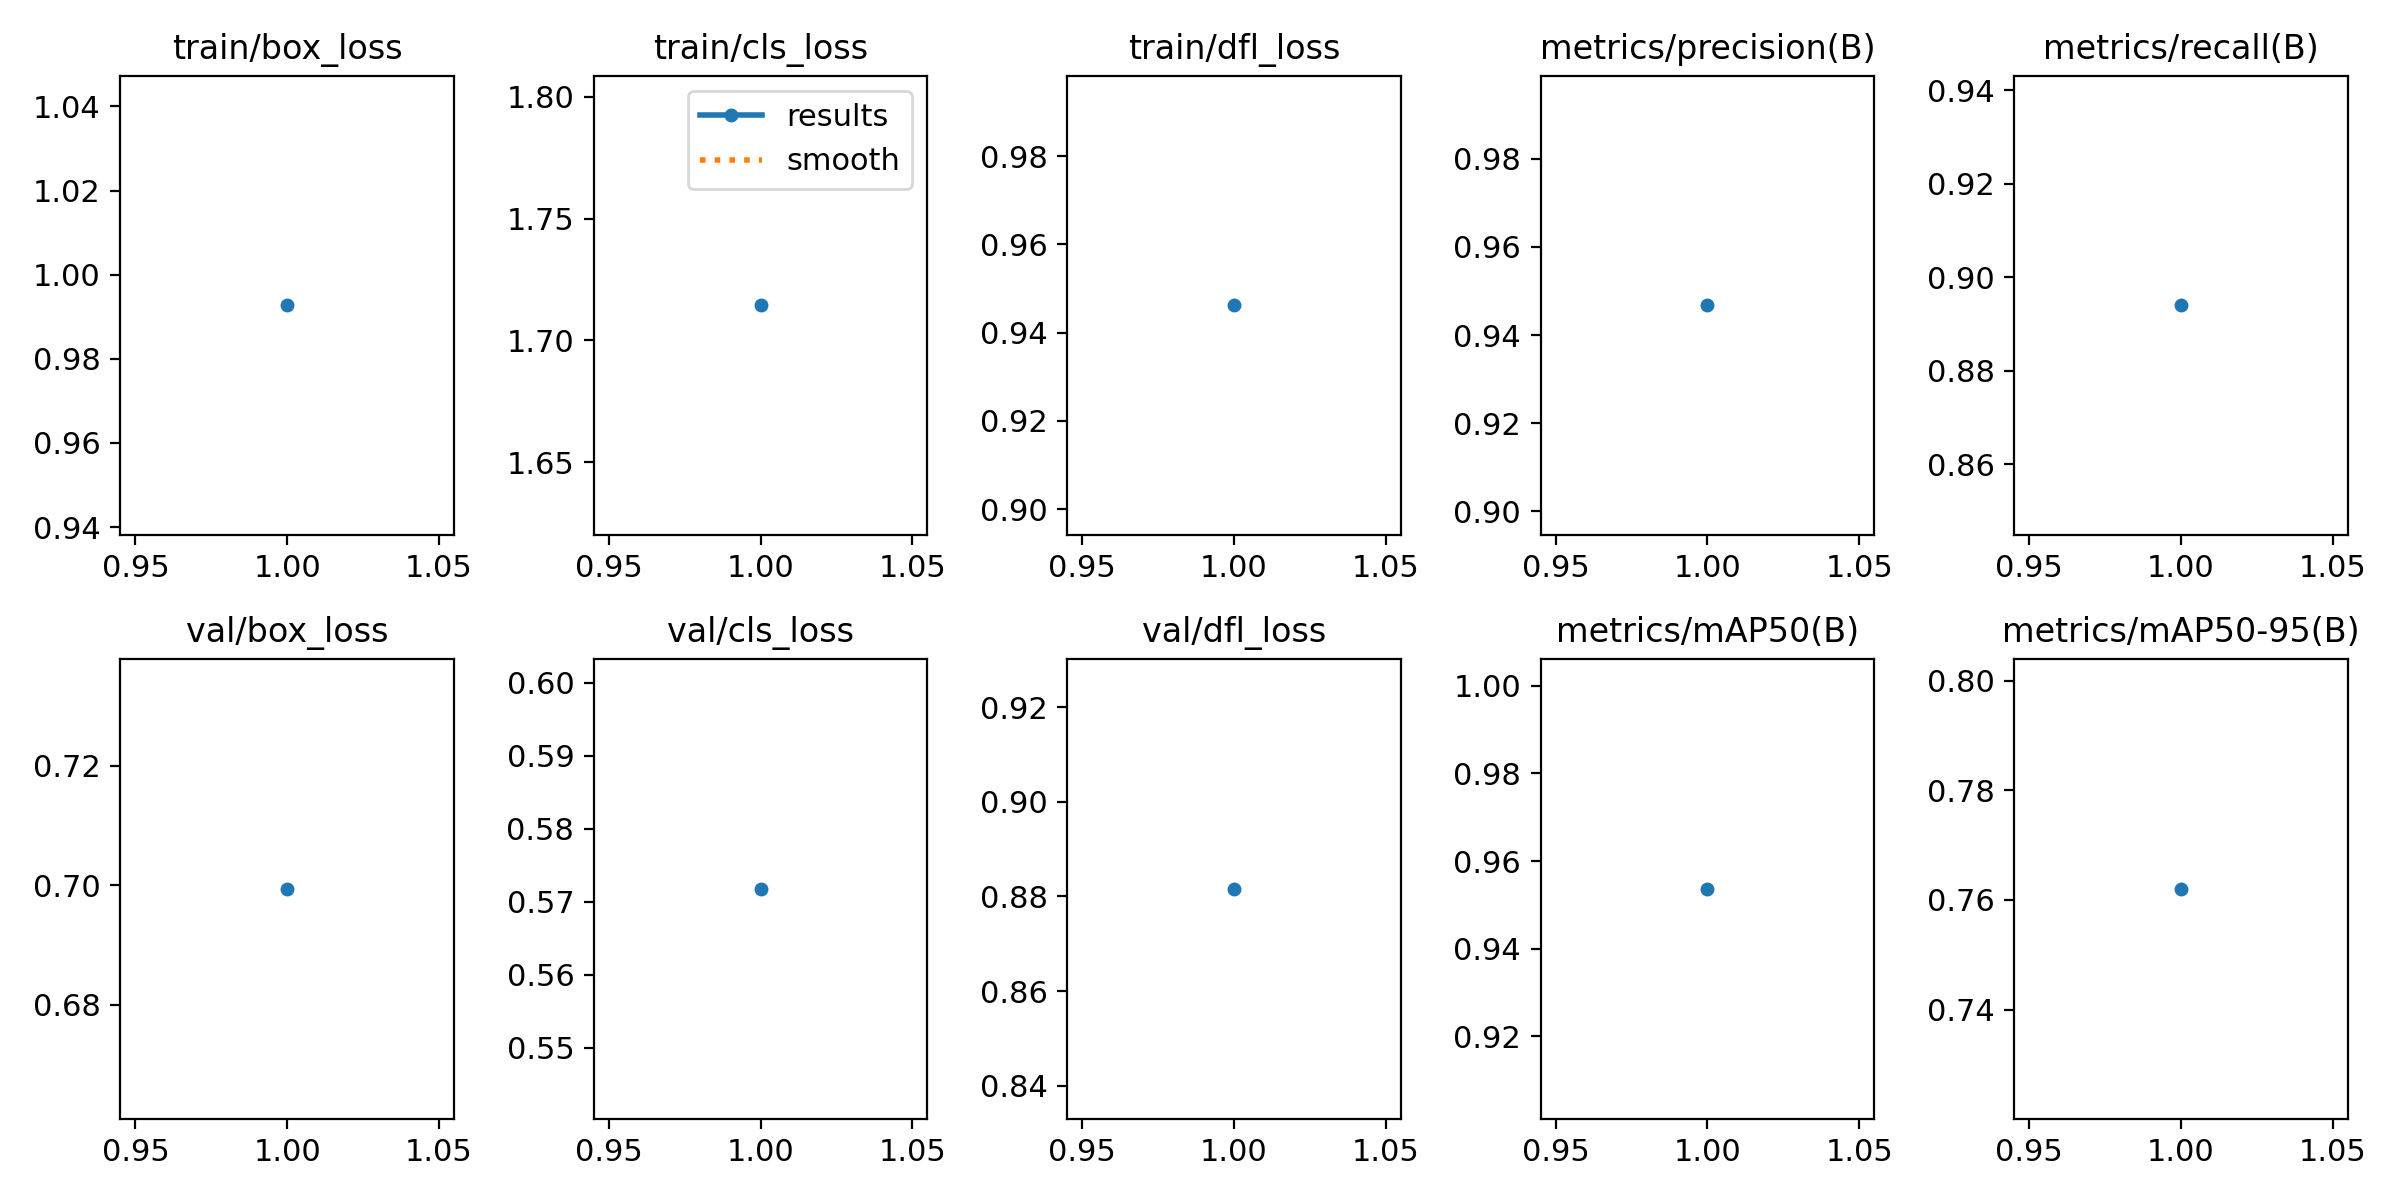

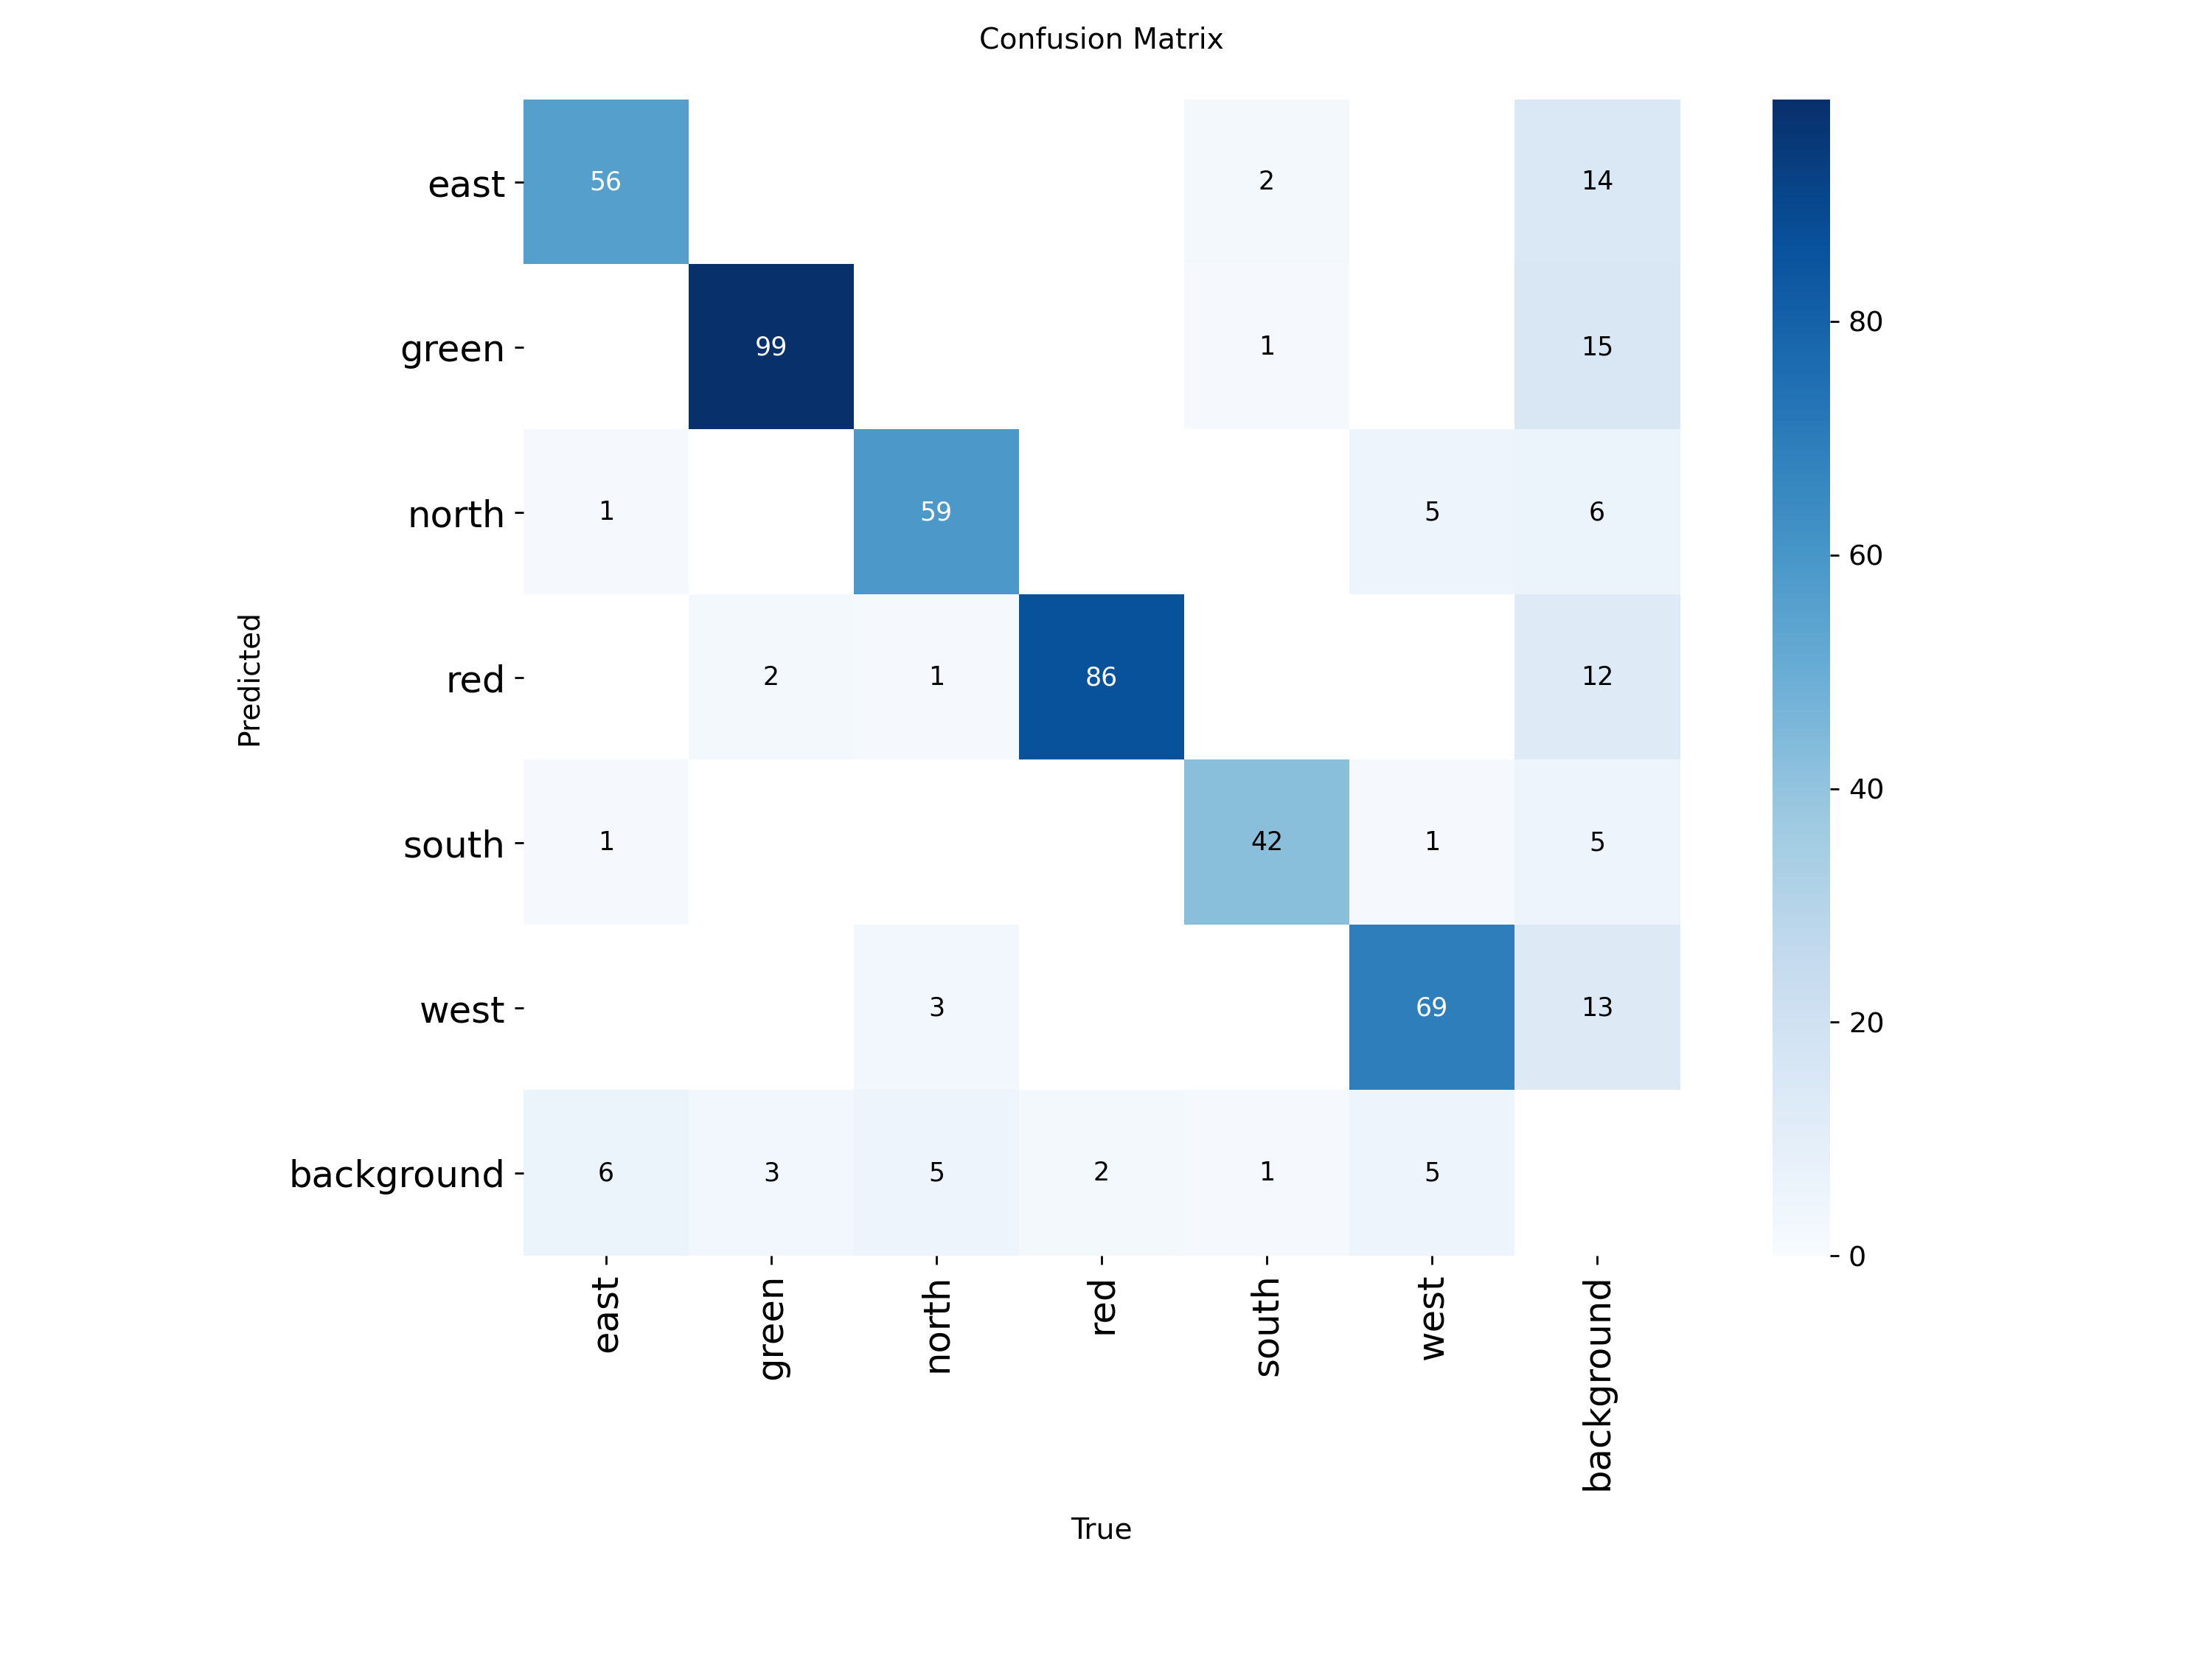

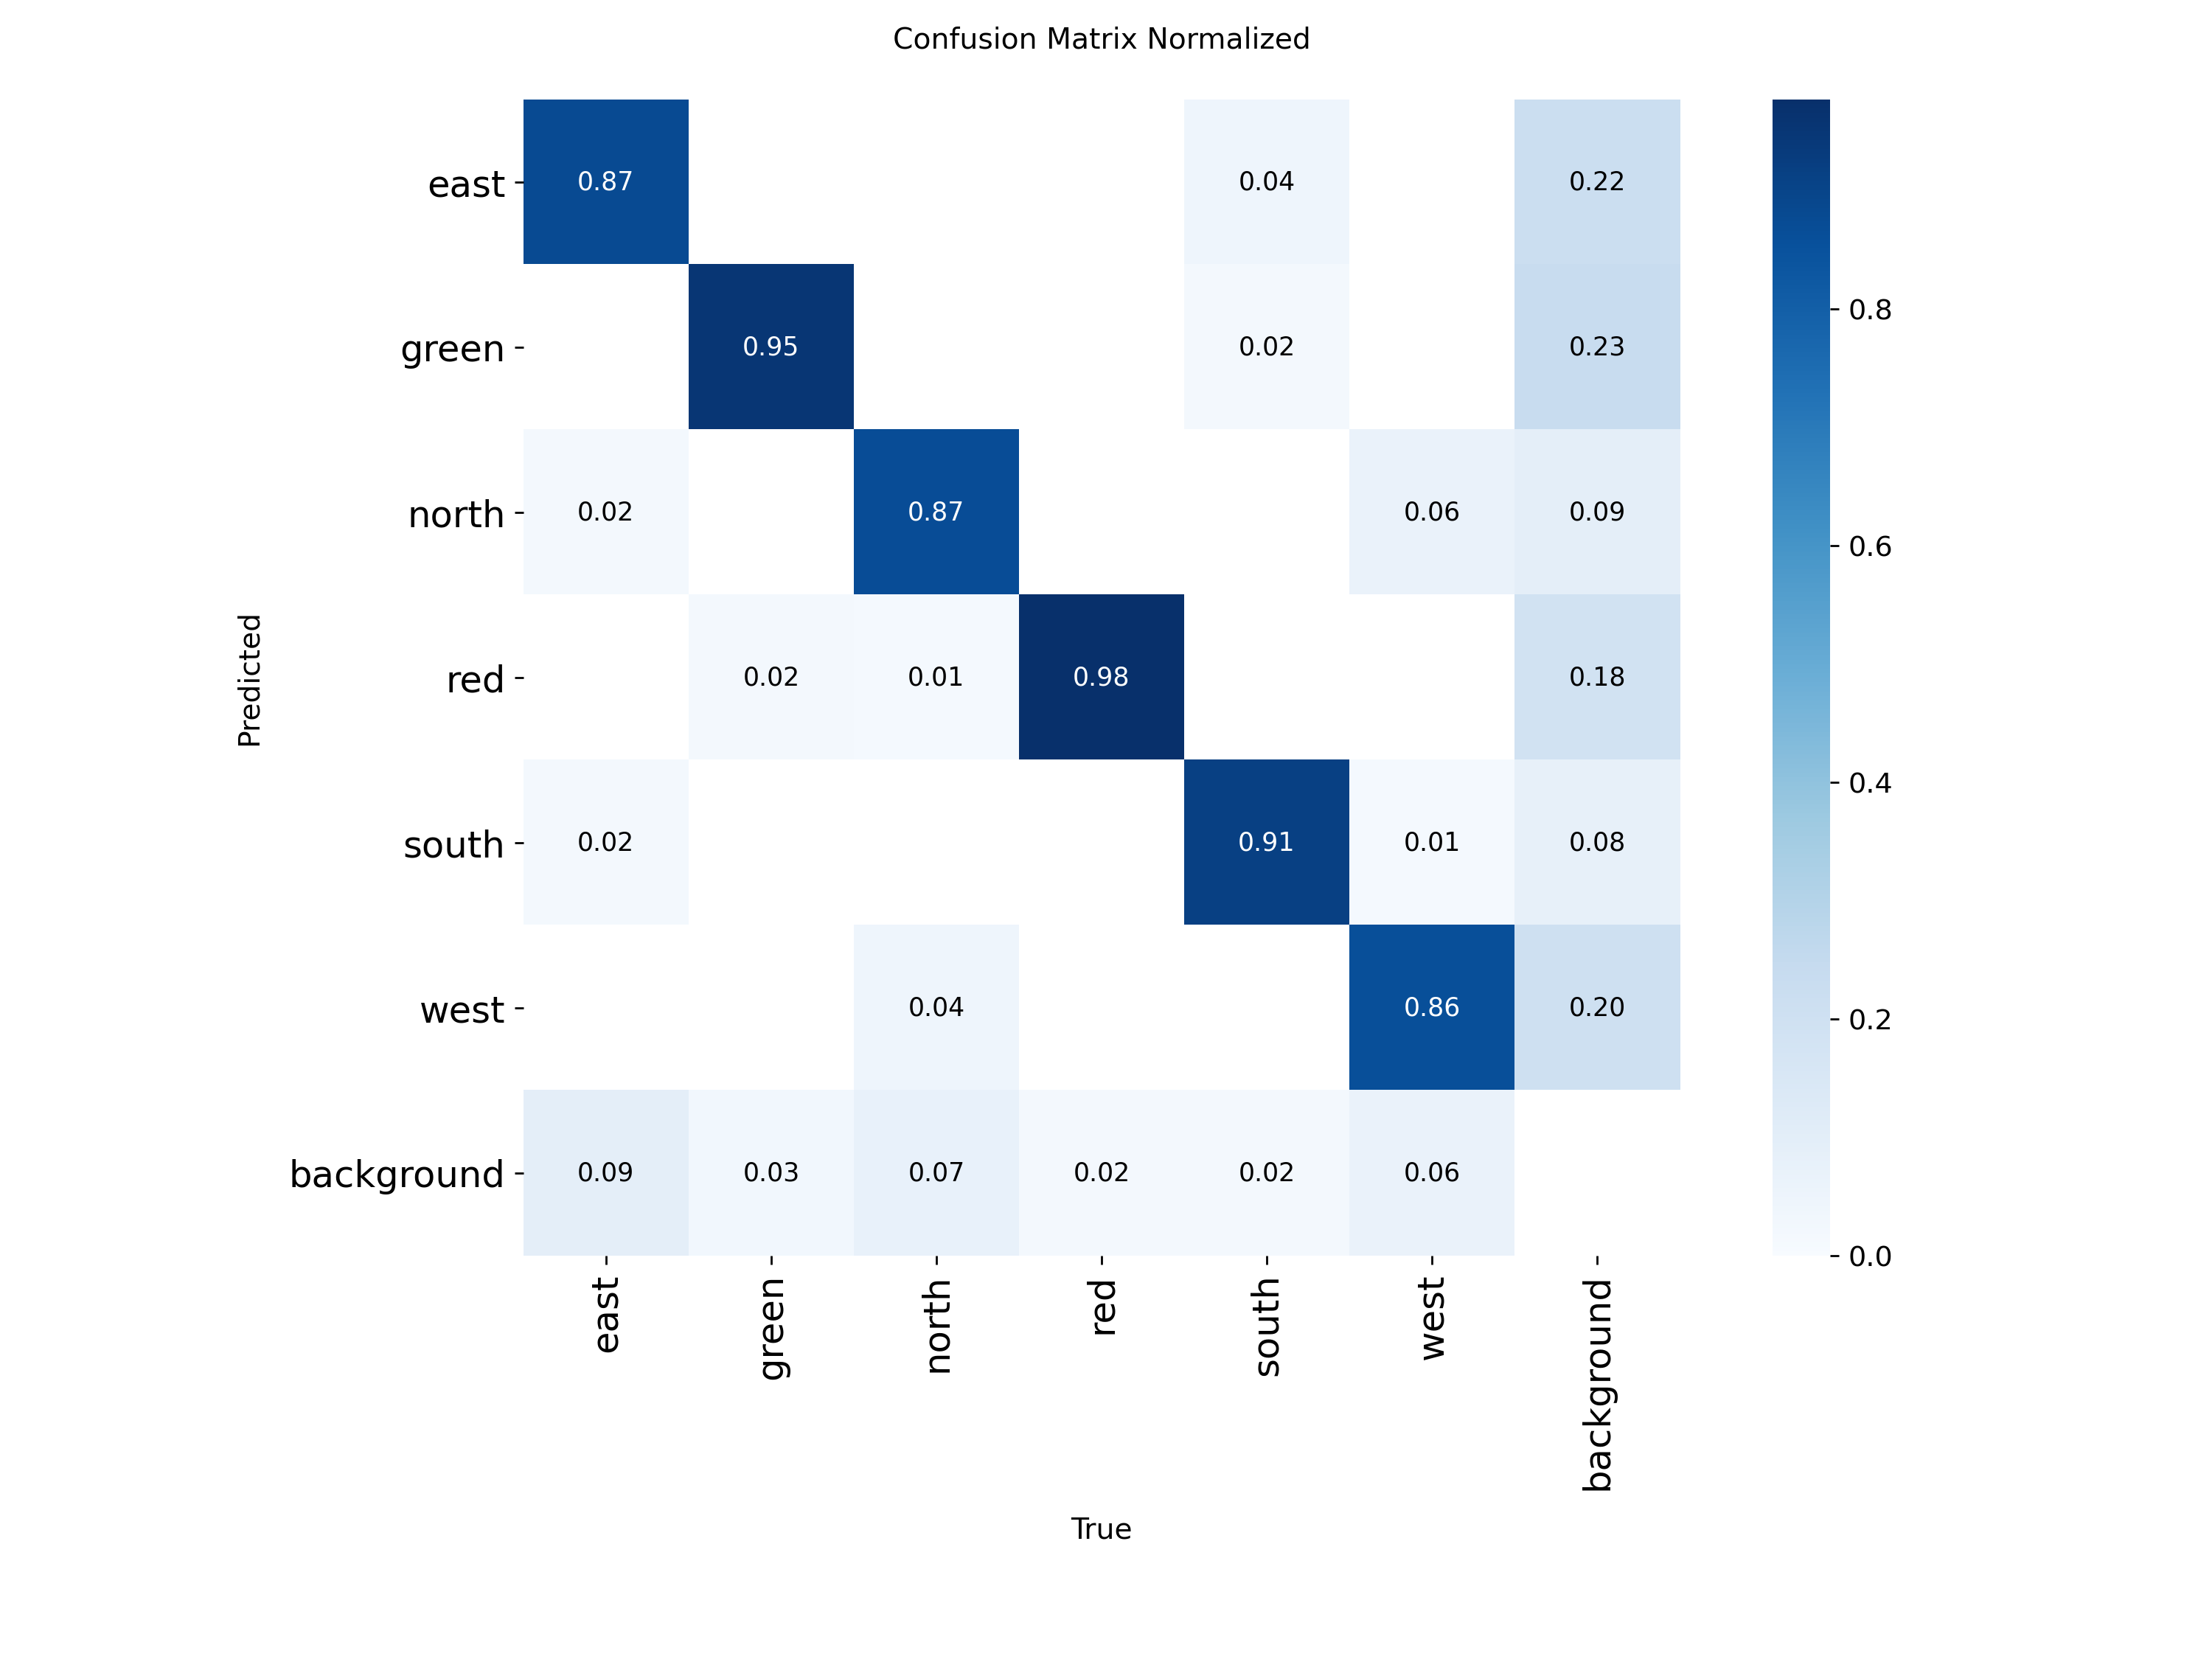

❌ Missing: PR_curve.png
❌ Missing: P_curve.png
❌ Missing: R_curve.png
❌ Missing: F1_curve.png


In [24]:
from IPython.display import Image, display

plots = [
    "results.png",
    "confusion_matrix.png",
    "confusion_matrix_normalized.png",
    "PR_curve.png",
    "P_curve.png",
    "R_curve.png",
    "F1_curve.png",
]
for p in plots:
    f = RUN_DIR / p
    if f.exists():
        display(Image(filename=str(f), width=950))
    else:
        print("❌ Missing:", p)


In [25]:
%cd {HOME}
!yolo task=detect mode=val model="{HOME}/runs/revised_v3_yolov8n/weights/best.pt" data="{DATA_YAML}" imgsz=640

/content/datasets
Ultralytics 8.3.240 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,006,818 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1656.6±462.0 MB/s, size: 41.1 KB)
val: Scanning /content/datasets/datasets/revised_data_set-3/valid/labels.cache... 320 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 320/320 5.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 20/20 4.3it/s 4.7s
                   all        320        450      0.947      0.896      0.955      0.766
                  east         63         64      0.853      0.814      0.891      0.707
                 green        102        104      0.943      0.955      0.985       0.79
                 north         68         68      0.938      0.883      0.951      0.777
                   red         83         88       0.97      0.977      0.985       0.79
   

## Validate Custom Model

In [26]:
%cd {HOME}
!yolo task=detect mode=predict model="{BEST}" conf=0.25 source="{Path(dataset.location) / 'test/images'}" \
save=True project="{RUN_DIR}" name="predict_test" exist_ok=True

/content/datasets
Ultralytics 8.3.240 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,006,818 parameters, 0 gradients, 8.1 GFLOPs

image 1/121 /content/datasets/datasets/revised_data_set-3/test/images/560d082f-14d1-4f85-a357-e691110fce43_png.rf.d88da5f4d2f88658c459386ddad99bbf.jpg: 640x640 1 green, 1 red, 8.8ms
image 2/121 /content/datasets/datasets/revised_data_set-3/test/images/6d1f33fd-7a20-4abc-8431-eeb2a8e51034_png.rf.53c4b12e9b64e868e73c1967f1dd5ea0.jpg: 640x640 1 green, 1 red, 7.3ms
image 3/121 /content/datasets/datasets/revised_data_set-3/test/images/76858a4e-f17d-4cc8-873d-79d614d0c7af_png.rf.f91d909dc2f0145904f74420b02a185b.jpg: 640x640 1 green, 7.3ms
image 4/121 /content/datasets/datasets/revised_data_set-3/test/images/caa61781-9afb-4278-a7a2-3c471cc87698_png.rf.4fd942f71bf8533553a78efbaecdf5c3.jpg: 640x640 1 green, 1 red, 7.2ms
image 5/121 /content/datasets/datasets/revised_data_set-3/test/images/east1080p_20230726_171403_p

Pred outputs: 121


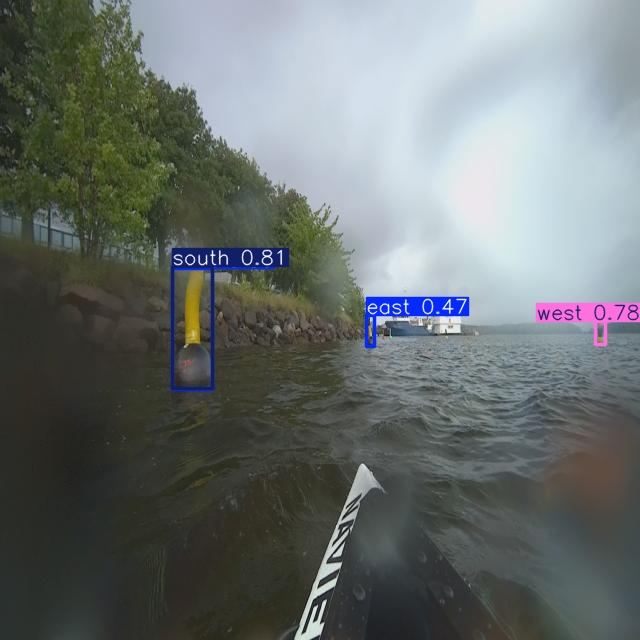

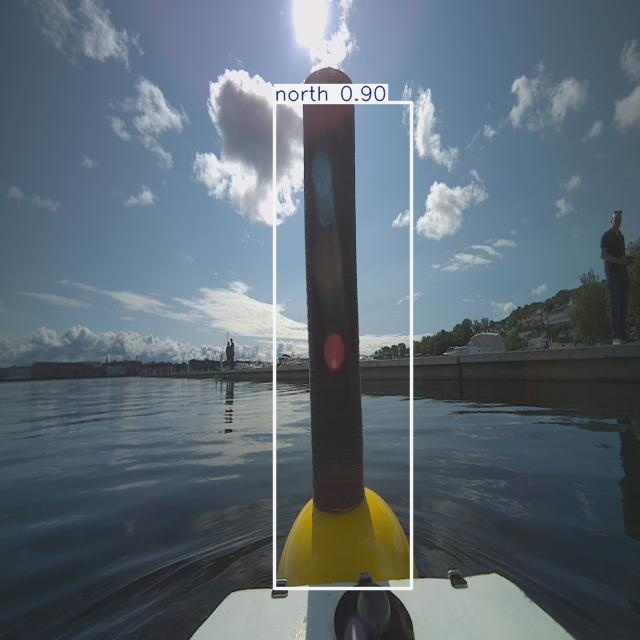

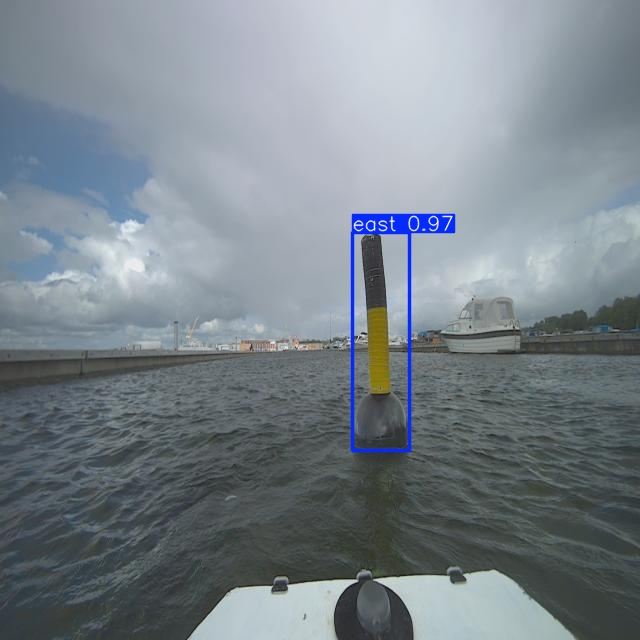

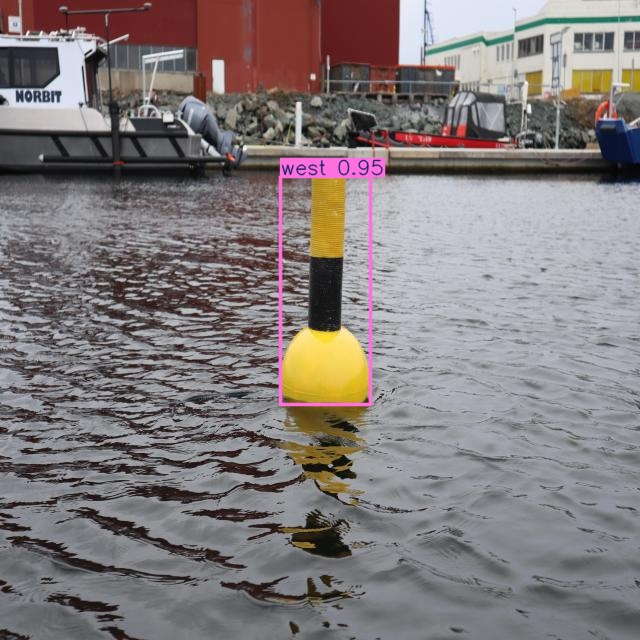

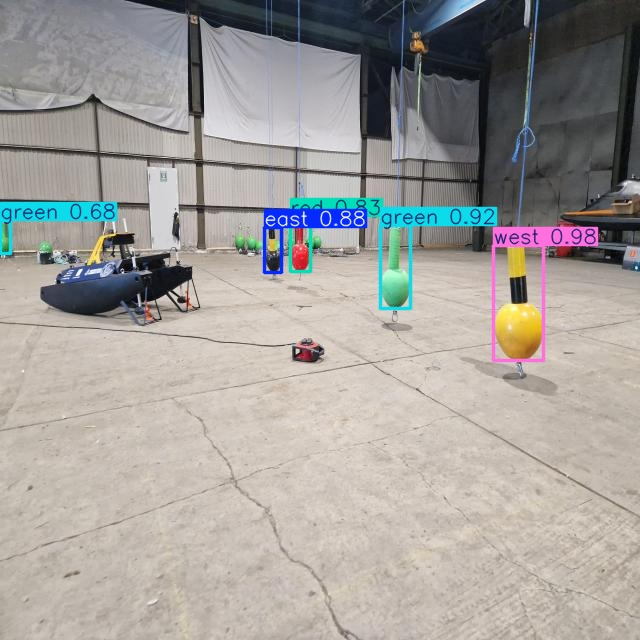

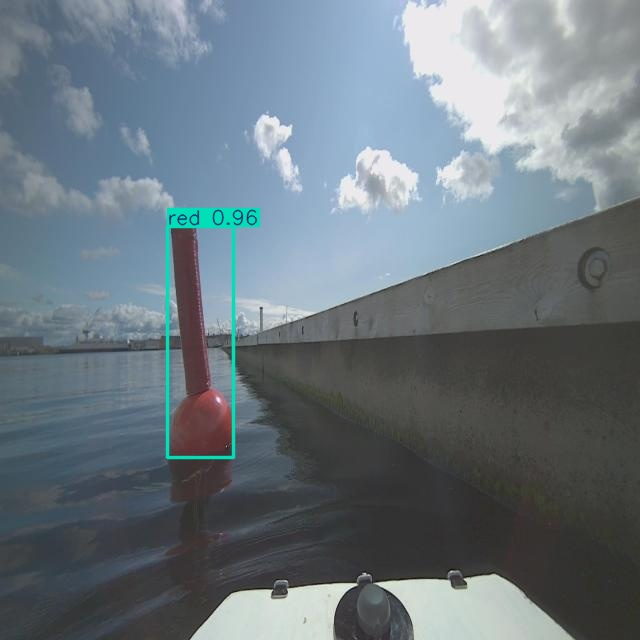

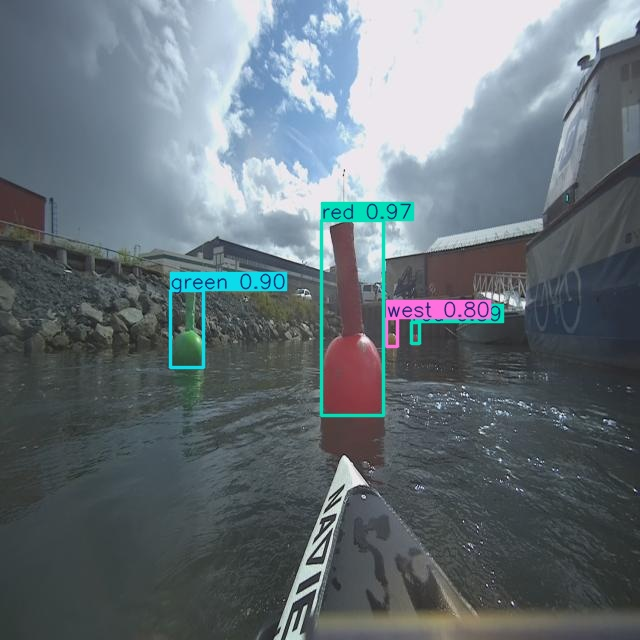

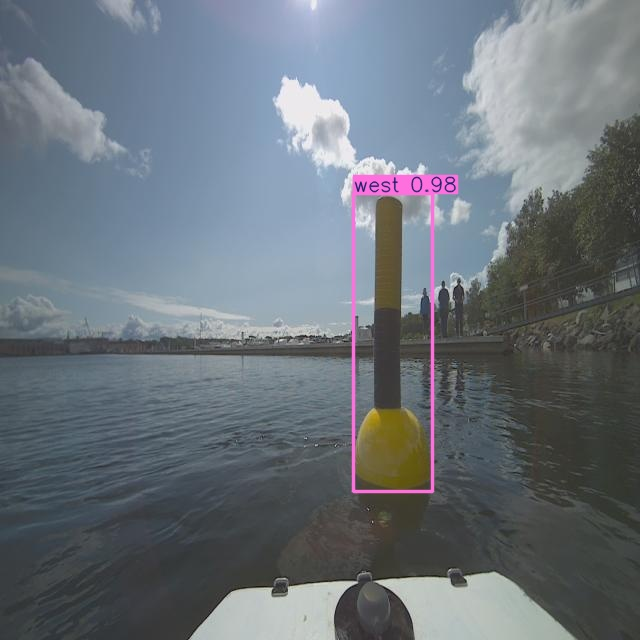

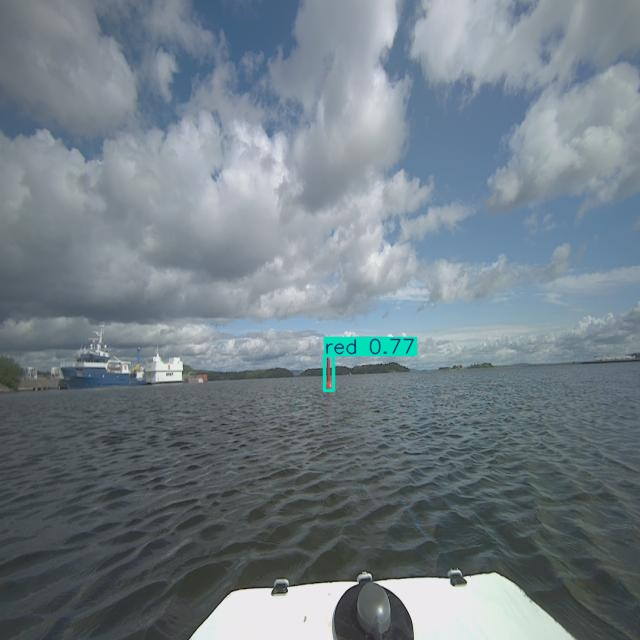

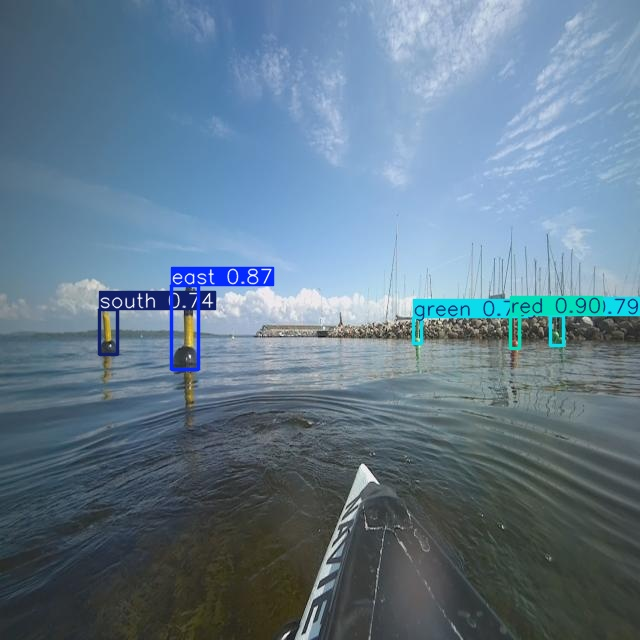

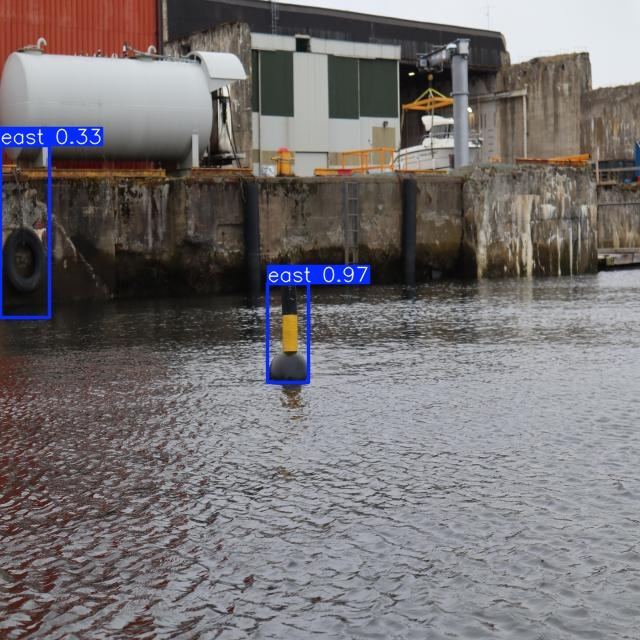

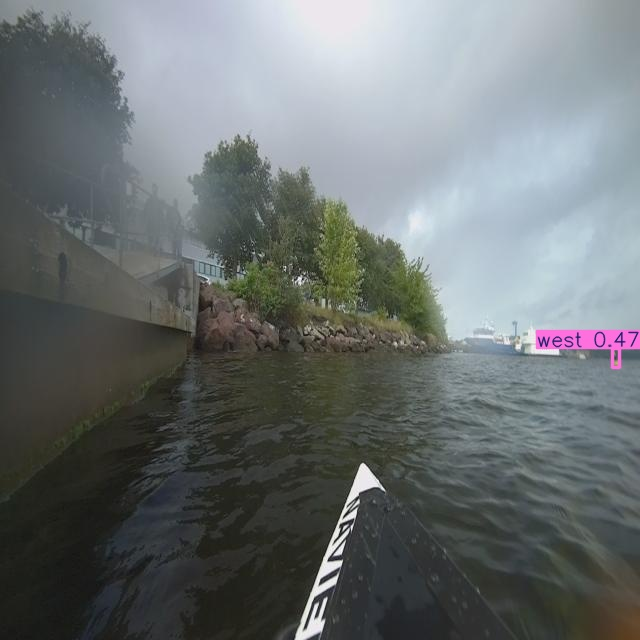

In [27]:
from pathlib import Path
from IPython.display import Image, display

pred_dir = RUN_DIR / "predict_test"
imgs = list(pred_dir.glob("*.jpg")) + list(pred_dir.glob("*.png"))

print("Pred outputs:", len(imgs))
for p in imgs[:12]:   # ilk 12 taneyi göster
    display(Image(filename=str(p), width=800))

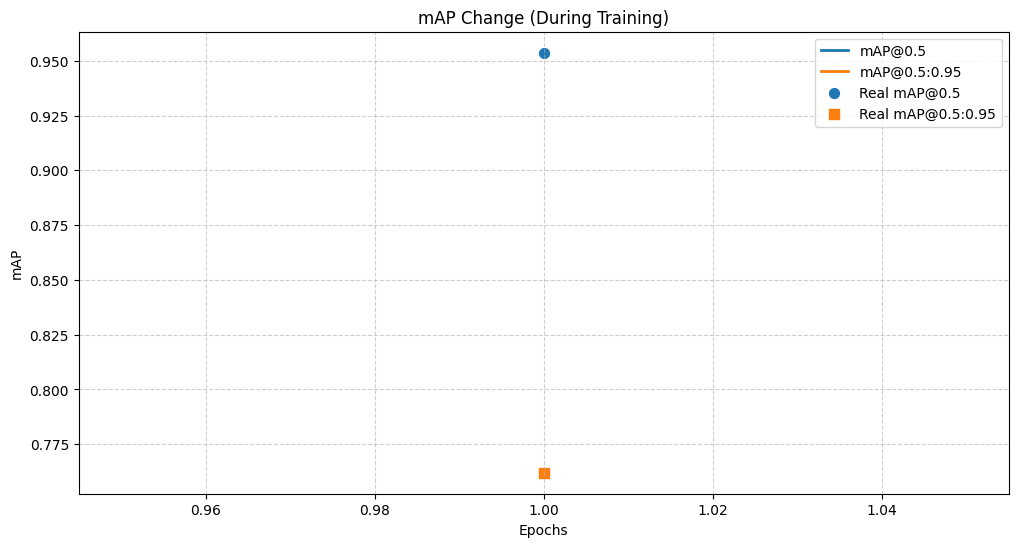

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

results_csv = RUN_DIR / "results.csv"
df = pd.read_csv(results_csv)

epochs = df["epoch"].values

map50_col = [c for c in df.columns if "metrics/mAP50" in c][0]
map5095_col = [c for c in df.columns if "metrics/mAP50-95" in c][0]

mAP_50 = df[map50_col].values
mAP_50_95 = df[map5095_col].values

smooth_epochs = np.linspace(float(epochs.min()), float(epochs.max()), 300)
smooth_map_50 = np.interp(smooth_epochs, epochs, mAP_50)
smooth_map_50_95 = np.interp(smooth_epochs, epochs, mAP_50_95)

plt.figure(figsize=(12, 6))
plt.plot(smooth_epochs, smooth_map_50, linewidth=2, label="mAP@0.5")
plt.plot(smooth_epochs, smooth_map_50_95, linewidth=2, label="mAP@0.5:0.95")
plt.scatter(epochs, mAP_50, marker="o", s=50, label="Real mAP@0.5")
plt.scatter(epochs, mAP_50_95, marker="s", s=50, label="Real mAP@0.5:0.95")
plt.xlabel("Epochs")
plt.ylabel("mAP")
plt.title("mAP Change (During Training)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.show()

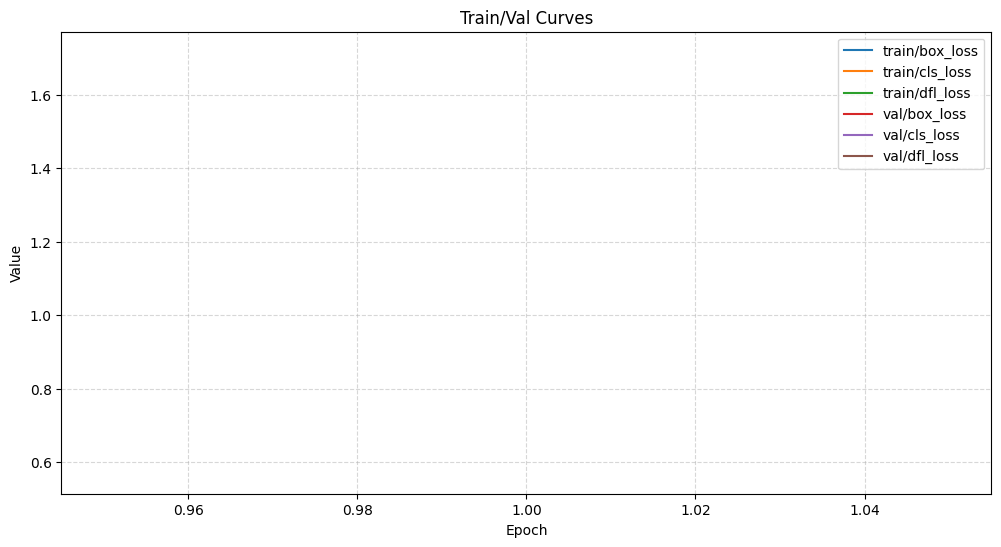

In [29]:
loss_cols = [c for c in df.columns if c.startswith("train/") or c.startswith("val/")]
plt.figure(figsize=(12, 6))
for c in loss_cols:
    plt.plot(df["epoch"], df[c], label=c)
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.title("Train/Val Curves")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.show()

## Inference with Custom Model

**NOTE:** Let's take a look at few results.

## 🏆 Congratulations

### Learning Resources

Roboflow has produced many resources that you may find interesting as you advance your knowledge of computer vision:

- [Roboflow Notebooks](https://github.com/roboflow/notebooks): A repository of over 20 notebooks that walk through how to train custom models with a range of model types, from YOLOv7 to SegFormer.
- [Roboflow YouTube](https://www.youtube.com/c/Roboflow): Our library of videos featuring deep dives into the latest in computer vision, detailed tutorials that accompany our notebooks, and more.
- [Roboflow Discuss](https://discuss.roboflow.com/): Have a question about how to do something on Roboflow? Ask your question on our discussion forum.
- [Roboflow Models](https://roboflow.com): Learn about state-of-the-art models and their performance. Find links and tutorials to guide your learning.

### Convert data formats

Roboflow provides free utilities to convert data between dozens of popular computer vision formats. Check out [Roboflow Formats](https://roboflow.com/formats) to find tutorials on how to convert data between formats in a few clicks.

### Connect computer vision to your project logic

[Roboflow Templates](https://roboflow.com/templates) is a public gallery of code snippets that you can use to connect computer vision to your project logic. Code snippets range from sending emails after inference to measuring object distance between detections.